In [1]:
from tensorflow.keras.datasets import mnist
import numpy as np


(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(train_images.shape)
print(len(train_labels))
print(train_images.dtype)
print(train_images.ndim)

print(test_images.shape)
print(len(test_labels))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28)
60000
uint8
3
(10000, 28, 28)
10000


In [2]:
train_images[:1]

array([[[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           3,  18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,
           0,   0,   0

In [3]:
train_labels


array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

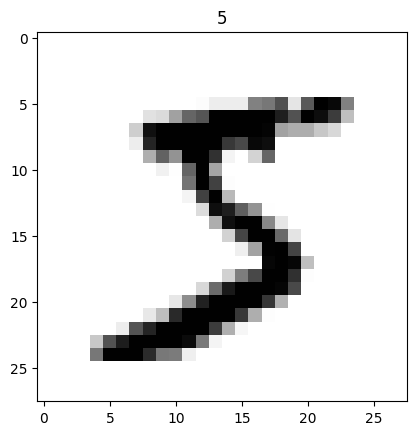

In [4]:
import matplotlib.pyplot as plt

digit = train_images[0]
plt.imshow(digit, cmap=plt.cm.binary)
plt.title(train_labels[0])
plt.show()

In [5]:
28*28

784

In [6]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(28*28,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [7]:
opt = keras.optimizers.Adam(learning_rate=0.01)

model.compile(optimizer='rmsprop',
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy", ])

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [10]:
train_images.shape

(60000, 784)

In [11]:
train_images[:1]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [12]:
history = model.fit(train_images,
                    train_labels,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8502 - loss: 0.5304 - val_accuracy: 0.9466 - val_loss: 0.1922
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9454 - loss: 0.1903 - val_accuracy: 0.9555 - val_loss: 0.1582
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9601 - loss: 0.1344 - val_accuracy: 0.9629 - val_loss: 0.1297
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9680 - loss: 0.1086 - val_accuracy: 0.9653 - val_loss: 0.1243
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9743 - loss: 0.0915 - val_accuracy: 0.9695 - val_loss: 0.1137
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9777 - loss: 0.0761 - val_accuracy: 0.9673 - val_loss: 0.1127
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9812 - loss: 0.0688 - val_accuracy: 0.9695 - val_loss: 0.1120
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9827 - loss: 0.0602 - 

In [13]:
history.history

{'accuracy': [0.9037500023841858,
  0.9492499828338623,
  0.9615416526794434,
  0.968999981880188,
  0.9739791750907898,
  0.9776041507720947,
  0.9805208444595337,
  0.9826874732971191,
  0.9838541746139526,
  0.9853958487510681],
 'loss': [0.3360511064529419,
  0.17516016960144043,
  0.13135787844657898,
  0.10607311129570007,
  0.08983328193426132,
  0.0779041275382042,
  0.07009834796190262,
  0.06165670230984688,
  0.056722600013017654,
  0.05167261138558388],
 'val_accuracy': [0.9465833306312561,
  0.9555000066757202,
  0.9629166722297668,
  0.9653333425521851,
  0.9695000052452087,
  0.9673333168029785,
  0.9695000052452087,
  0.968833327293396,
  0.9708333611488342,
  0.9711666703224182],
 'val_loss': [0.19223277270793915,
  0.15815265476703644,
  0.12968596816062927,
  0.12428013235330582,
  0.11372912675142288,
  0.11267431825399399,
  0.11200865358114243,
  0.11261552572250366,
  0.10884235799312592,
  0.11035117506980896]}

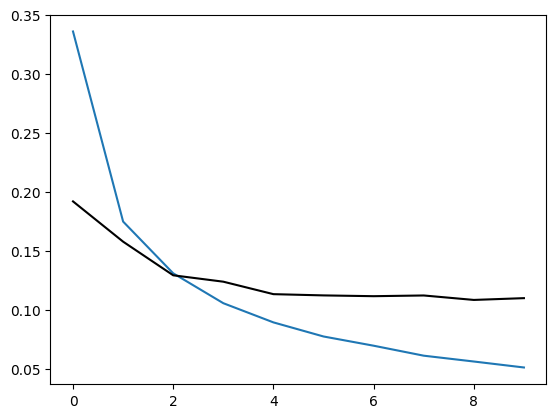

In [14]:
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure()
plt.plot(loss)
plt.plot(val_loss,'k')
plt.show()


In [15]:
test_labels[0]

np.uint8(7)

In [16]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([[7.4998585e-10, 5.4353408e-13, 2.9297723e-08, 1.4444409e-05,
        3.4195191e-16, 2.4295893e-08, 4.2046504e-17, 9.9998522e-01,
        5.0871840e-08, 2.6281637e-07],
       [1.3085968e-10, 1.7583377e-05, 9.9998236e-01, 2.1587981e-08,
        3.5726703e-22, 4.6695986e-10, 3.1694449e-11, 7.1017060e-25,
        1.1940670e-09, 1.9298633e-23],
       [3.4185013e-07, 9.9926847e-01, 8.8309265e-05, 6.7030400e-05,
        1.1944471e-06, 2.5241825e-06, 9.5945443e-06, 1.4861619e-04,
        4.1187461e-04, 2.1347730e-06],
       [9.9997997e-01, 3.2815124e-14, 1.6560668e-07, 6.5871390e-08,
        5.8993210e-10, 4.8775782e-08, 1.5395735e-05, 3.1930060e-06,
        3.4631276e-10, 1.1605889e-06],
       [8.1421030e-07, 3.6145921e-14, 2.8146084e-07, 2.4593422e-08,
        9.9640489e-01, 1.4770936e-09, 2.8224749e-08, 7.0824943e-05,
        3.9892367e-07, 3.5227768e-03],
       [2.6283213e-09, 9.9979538e-01, 9.0885362e-07, 3.0303411e-06,
        4.0920554e-08, 1.5229992e-09, 1.3636027e-08, 1.87

In [17]:
predictions[0].argmax()

np.int64(7)

In [18]:
test_labels[0]

np.uint8(7)

**Evaluating the model on new data**

In [19]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9722 - loss: 0.1042
test_acc: 0.974399983882904


### Manipulating tensors in NumPy

In [20]:
# (train_images, train_labels), (test_images, test_labels) = mnist.load_data()


# my_slice = train_images[10:100]
# my_slice.shape

# my_slice = train_images[10:100, :, :]
# my_slice.shape


# my_slice = train_images[10:100, 0:28, 0:28]
# my_slice.shape

# my_slice = train_images[:, 14:, 14:]
# my_slice.shape

# my_slice = train_images[:, 7:-7, 7:-7]
# my_slice.shape

### The notion of data batches

In [21]:
batch = train_images[:128]

batch = train_images[128:256]

n = 3
batch = train_images[128 * n:128 * (n + 1)]

Extração de features com modelo treinado.

In [22]:
def build_model():
    # model = keras.Sequential()
    # model.add(layers.Dense(512, input_shape=(28*28,), activation="relu", name="input"))
    # model.add(layers.Dense(2, activation="ReLU", name="layer_2")) # usar 2 e testar LeakyReLU
    # model.add(layers.Dense(10, activation="softmax", name="output"))


    camada_densa_1 = layers.Dense(512, activation="relu")

    input = layers.Input(shape=(28*28,))
    x = camada_densa_1(input)
    x = layers.Dense(2, name='features')(x) # usar 2 e testar LeakyReLU
    output = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs=input, outputs=output)

    model.compile(optimizer="rmsprop",
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])

    model.summary()

    return model

model = build_model()

history = model.fit(train_images, train_labels, epochs=20, batch_size=128)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Dense)                │ (None, 2)              │         1,026 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │            30 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,976 (1.54 MB)

 Trainable params: 402,976 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4718 - loss: 1.3386
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8469 - loss: 0.5899
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8935 - loss: 0.4300
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9135 - loss: 0.3579
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9278 - loss: 0.2936
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9399 - loss: 0.2430
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9467 - loss: 0.2164
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9522 - loss: 0.1894
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9577 - loss: 0.1783
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9595 - loss: 0.1565
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9666 - loss: 0.1347
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

In [23]:
# model.layers[1].weights

In [24]:
# defino um novo modelo

feature_extractor = keras.Model(
    inputs = model.inputs,
    outputs = model.get_layer(name="features").output,
)


features = feature_extractor(test_images)
print(features.shape) # uma imagem de 784 agora pode ser representada por um vetor de 2 dimensões

(10000, 2)


C:\Users\rafac\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_3']. Received: the structure of inputs=*
  warnings.warn(


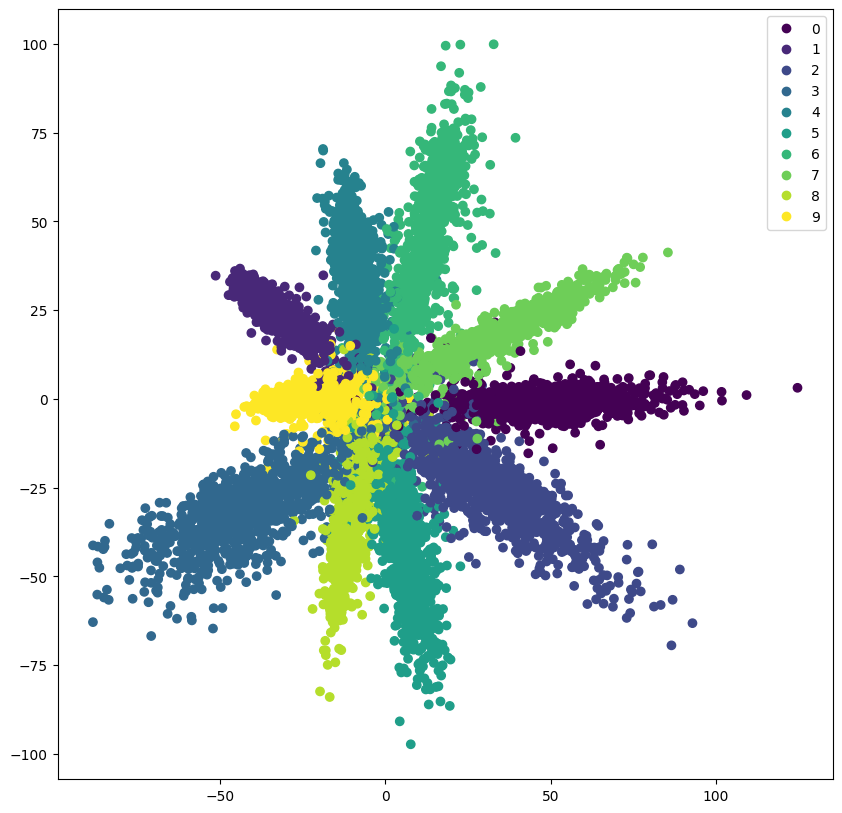

In [25]:
plt.figure(figsize=(10,10))
scatter = plt.scatter(features[:,0], features[:,1], c=test_labels)
plt.legend(handles=scatter.legend_elements()[0], labels=[str(i) for i in range(0,10)])
plt.show()

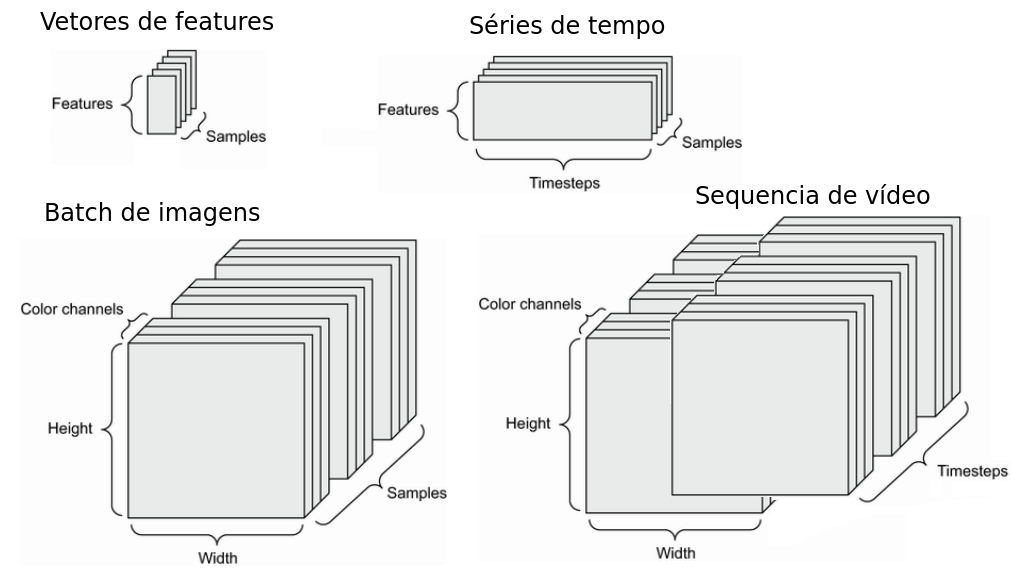